# <font size=6><b>Lec03.[실습]영화유사도
* https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

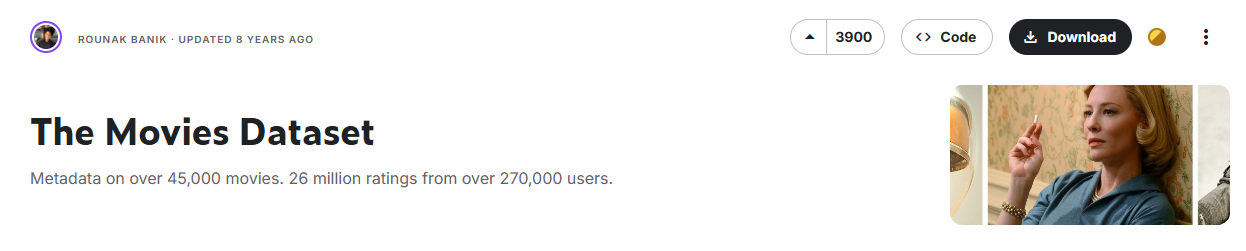

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

# -------------------------------------------------------------- 토큰화
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.preprocessing.text import Tokenizer

# -------------------------------------------------------------- 유사도
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer


#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>Data Load

In [2]:
movie = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\LLM\movie\movies_metadata.csv", low_memory=False)
movie.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",NaN,8844,tt0113497,en,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.",17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Interscope Communications', 'id': 10201}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",NaN,15602,tt0113228,en,Grumpier Old Men,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait shop, alarming the locals who worry she'll scare the fish away. But she's less interested in seafood than she is in cooking up a hot time with Max.",11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name': 'Lancaster Gate', 'id': 19464}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False,6.5,92.0


In [3]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [4]:
movie.shape

(45466, 24)

In [5]:
print(movie.shape)
movie = movie.drop_duplicates(subset=['overview'])
print(movie.shape)

(45466, 24)
(44308, 24)


In [6]:
print(movie.shape)
movie = movie.dropna(subset= ['overview'],axis=0)
print(movie.shape)

(44308, 24)
(44307, 24)


In [7]:
movie[movie['overview'].duplicated() == True]

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count


In [8]:
movie = movie[['title','overview']].head(20000)
movie.head(2)

,title,overview
0,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences."
1,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures."


# <b>유사도

## 불용어 처리

In [9]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [10]:
stop_words_list = stopwords.words('english')
print('불용어 개수 :', len(stop_words_list))
print('불용어 5개 출력 :',stop_words_list[:5])

불용어 개수 : 198
불용어 5개 출력 : ['a', 'about', 'above', 'after', 'again']


## [방법1] Tokenizer 토큰화 : 사전 인덱스 기반

In [11]:
import re

def my_stopwords(text):
    text = text.lower()
    re_text = re.findall(r'\b[a-z]{2,}\b', text)

    re_stop_text = [word for word in re_text
                    if word not in stop_words_list]
    return " ".join(re_stop_text)

In [12]:
my_stopwords(" i like a cat and dog and i am are is have a notebook")

'like cat dog notebook'

In [13]:
movie['overview_clean'] = movie['overview'].apply(my_stopwords)
movie.head(2)

,title,overview,overview_clean
0,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",led woody andy toys live happily room andy birthday brings buzz lightyear onto scene afraid losing place andy heart woody plots buzz circumstances separate buzz woody owner duo eventually learns put aside differences
1,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.",siblings judy peter discover enchanted board game opens door magical world unwittingly invite alan adult trapped inside game years living room alan hope freedom finish game proves risky three find running giant rhinoceroses evil monkeys terrifying creatures


In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tk = Tokenizer()
tk.fit_on_texts(movie['overview'])           # -------- [1] 문자열
#print(tk.word_index)                       # -------- 사전확인 : 단어인덱스
#print(tk.word_counts)                      # -------- 사전확인 : 단어빈도

res = tk.texts_to_sequences(movie['overview'])  # -------- [2] 임베딩(숫자화)
pad = pad_sequences(res, padding='post')        # -------- [3] 패딩

print(pad.shape)
print(pad)

(20000, 185)
[[  504    15  4156 ...     0     0     0]
 [   21  2688  4036 ...     0     0     0]
 [    2    46   564 ...     0     0     0]
 ...
 [ 2416  2168  1868 ...     0     0     0]
 [14302 11759  3897 ...     0     0     0]
 [  781  3257     3 ...     0     0     0]]


## [방법1] TF-IDF 토큰화 : 카운트기반
* TF-IDF(Term Frequency-Inverse Document Frequency)
* 단어빈도 + 단어가 나온 문서의 역수

In [15]:
tfidf_vt = TfidfVectorizer(stop_words = stop_words_list, binary=True, token_pattern=r'\bw[a-z]{2,}\b')
res = tfidf_vt.fit_transform(movie['overview'])  # -------- 1D
#print(tfidf_vt.vocabulary_)

print(res.shape)
print(tfidf_vt.get_feature_names_out())

tfidf = pd.DataFrame(res.toarray(), columns=tfidf_vt.get_feature_names_out(), index=movie['title'])
tfidf

(20000, 1220)
['waafs' 'wabash' 'wabc' ... 'wyoming' 'wyss' 'wyvern']


,waafs,wabash,wabc,wachati,wachootoos,wachowskis,wacked,wackiest,wackness,wacko,wacky,waco,wad,wada,waddlesworth,waddling,wade,wades,wadsworth,wadsworths,wadzilla,wafers,waffen,waffles,wag,wage,waged,wagen,wager,wagering,wagers,wages,wagglebury,waggomans,waging,wagner,wagnerian,wagon,wagonload,wagons,wagstaff,wah,waheeda,wahlberg,wahun,wai,waif,waihau,wail,wainscott,...,wronke,wrote,wrought,wry,wschodniej,wsu,wszystkimi,wto,wuba,wuhl,wulkow,wunderkind,wuornos,wuppertal,wurdalak,wurttemburg,wusa,wushu,wuthering,wuxia,wwe,wwf,wwi,wwii,wwiii,www,wyatt,wycliffe,wydell,wyke,wyld,wyler,wylie,wymaga,wyman,wymore,wyn,wynant,wyndham,wynette,wynkowski,wynn,wynne,wynnegate,wynorski,wynter,wyo,wyoming,wyss,wyvern
title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Toy Story,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Jumanji,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Grumpier Old Men,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Waiting to Exhale,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Father of the Bride Part II,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Comedy Central Roast of Bob Saget,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tiny Toon Adventures: How I Spent My Vacation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

## 유사도측정
* cosine_Similarity

### [방법1] Tokenizer matrix 사용

In [22]:
idx_cos_matrix = cosine_similarity(pad, pad)

In [23]:
idx_cos_matrix.shape

(20000, 20000)

In [24]:
idx_cos_df = pd.DataFrame(idx_cos_matrix, index=movie['title'], columns =movie['title'])
idx_cos_df.head()

title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II,Heat,Sabrina,Tom and Huck,Sudden Death,GoldenEye,The American President,Dracula: Dead and Loving It,Balto,Nixon,Cutthroat Island,Casino,Sense and Sensibility,Four Rooms,Ace Ventura: When Nature Calls,Money Train,Get Shorty,Copycat,Assassins,Powder,Leaving Las Vegas,Othello,Now and Then,Persuasion,The City of Lost Children,Shanghai Triad,Dangerous Minds,Twelve Monkeys,Babe,Carrington,Dead Man Walking,Across the Sea of Time,It Takes Two,Clueless,"Cry, the Beloved Country",Richard III,Dead Presidents,Restoration,Mortal Kombat,To Die For,How To Make An American Quilt,Se7en,Pocahontas,When Night Is Falling,The Usual Suspects,Guardian Angel,...,The Central Park Five,The Collection,The Cherry Orchard: Blossoming,FDR: American Badass!,All Superheroes Must Die,Jean Renoir: Part One - From La Belle Époque to World War II,Booker's Place: A Mississippi Story,Girl Walk // All Day,Las Acacias,Just Ask My Children,Never Too Young to Die,Remember the Daze,Waiting for Lightning,Yesterday's Enemy,Young People,The Villain,Soldiers of Fortune,Rurouni Kenshin,Les Misérables,Extracted,Stevie,Mansome,Les Misérables,Les Miserables,The Big Street,The True Meaning of Christmas Specials,Great Escape: The Untold Story,Kenji Mizoguchi: The Life of a Film Director,Cornelis,Promised Land,Neo Ned,Offender,Confessions of a Window Cleaner,The Man Who Haunted Himself,Dakota Skye,A Demon in My View,The Immaculate Conception of Little Dizzle,Judas Kiss,Confessions of a Pop Performer,Private Romeo,Role/Play,I Know What I Saw,The Sweeney,English Vinglish,Fish Story,Comedy Central Roast of Bob Saget,Tiny Toon Adventures: How I Spent My Vacation,Trapped in the Closet: Chapters 1-12,The Sea of Grass,The Visitors
title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Toy Story,1.000000,0.166010,0.336459,0.324942,0.212893,0.242327,0.299475,0.127565,0.190225,0.128217,0.093904,0.143173,0.354125,0.162903,0.640994,0.230322,0.166547,0.325775,0.276084,0.093239,0.487292,0.051898,0.183643,0.393398,0.087218,0.326216,0.132004,0.254954,0.427944,0.310872,0.562933,0.151222,0.070224,0.180479,0.092490,0.058244,0.189126,0.202596,0.230454,0.142220,0.116590,0.151669,0.100393,0.124380,0.137368,0.075403,0.152797,0.046276,0.103232,0.440354,...,0.185833,0.162225,0.191012,0.180081,0.553587,0.052115,0.104594,0.062906,0.195475,0.079767,0.346633,0.253141,0.053216,0.091582,0.021699,0.098793,0.052883,0.256495,0.044038,0.161529,0.062089,0.232707,0.107169,0.152482,0.315868,0.223323,0.635728,0.167029,0.101022,0.205173,0.172425,0.135522,0.096911,0.108482,0.047280,0.013867,0.111327,0.037707,0.309711,0.079878,0.306821,0.135080,0.197899,0.034453,0.132662,0.023447,0.050884,0.019716,0.155549,0.467719
Jumanji,0.166010,1.000000,0.050881,0.059267,0.158731,0.212053,0.095360,0.292731,0.041130,0.026197,0.152256,0.167303,0.044055,0.070352,0.187001,0.028979,0.118708,0.042363,0.109351,0.027995,0.090372,0.069363,0.064392,0.084949,0.061859,0.096290,0.149600,0.125537,0.025010,0.040300,0.125579,0.061292,0.146938,0.212667,0.048501,0.037210,0.182265,0.065924,0.029857,0.105252,0.311495,0.040735,0.056338,0.045010,0.077359,0.205350,0.075087,0.076149,0.248072,0.127190,...,0.271077,0.152345,0.084296,0.225115,0.128952,0.043660,0.073403,0.136656,0.064237,0.078247,0.037233,0.079053,0.036269,0.043402,0.097544,0.057688,0.039606,0.104411,0.102422,0.093686,0.017580,0.047830,0.391757,0.154784,0.049515,0.038111,0.093542,0.113332,0.044640,0.072164,0.067974,0.020999,0.105065,0.092585,0.122004,0.018775,0.158038,0.094067,0.191665,0.069940,0.117558,0.081059,0.108159,0.075562,0.176043,0.098970,0.053043,0.095425,0.126736,0.036182
Grumpier Old Men,0.336459,0.050881,1.000000,0.271891,0.259519,0.225944,0.061626,0.121206,0.208756,0.204653,0.238275,0.173294,0.111405,0.184617,0.274054,0.024471,0.109507,0.451016,0.298269,0.110180,0.215794,0.040587,0.146202,0.068705,0.325866,0.140711,0.223758,0.288450,0.057062,0.

### [방법2] TF-IDF matrix 사용

In [17]:
tfidf_cos_matrix = cosine_similarity(tfidf, tfidf)

In [25]:
tfidf_cos_matrix.shape

(20000, 20000)

In [30]:
tfidf_cos_df = pd.DataFrame(tfidf_cos_matrix, index=movie['title'], columns =movie['title'])
tfidf_cos_matrix.head()

title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II,Heat,Sabrina,Tom and Huck,Sudden Death,GoldenEye,The American President,Dracula: Dead and Loving It,Balto,Nixon,Cutthroat Island,Casino,Sense and Sensibility,Four Rooms,Ace Ventura: When Nature Calls,Money Train,Get Shorty,Copycat,Assassins,Powder,Leaving Las Vegas,Othello,Now and Then,Persuasion,The City of Lost Children,Shanghai Triad,Dangerous Minds,Twelve Monkeys,Babe,Carrington,Dead Man Walking,Across the Sea of Time,It Takes Two,Clueless,"Cry, the Beloved Country",Richard III,Dead Presidents,Restoration,Mortal Kombat,To Die For,How To Make An American Quilt,Se7en,Pocahontas,When Night Is Falling,The Usual Suspects,Guardian Angel,...,The Central Park Five,The Collection,The Cherry Orchard: Blossoming,FDR: American Badass!,All Superheroes Must Die,Jean Renoir: Part One - From La Belle Époque to World War II,Booker's Place: A Mississippi Story,Girl Walk // All Day,Las Acacias,Just Ask My Children,Never Too Young to Die,Remember the Daze,Waiting for Lightning,Yesterday's Enemy,Young People,The Villain,Soldiers of Fortune,Rurouni Kenshin,Les Misérables,Extracted,Stevie,Mansome,Les Misérables,Les Miserables,The Big Street,The True Meaning of Christmas Specials,Great Escape: The Untold Story,Kenji Mizoguchi: The Life of a Film Director,Cornelis,Promised Land,Neo Ned,Offender,Confessions of a Window Cleaner,The Man Who Haunted Himself,Dakota Skye,A Demon in My View,The Immaculate Conception of Little Dizzle,Judas Kiss,Confessions of a Pop Performer,Private Romeo,Role/Play,I Know What I Saw,The Sweeney,English Vinglish,Fish Story,Comedy Central Roast of Bob Saget,Tiny Toon Adventures: How I Spent My Vacation,Trapped in the Closet: Chapters 1-12,The Sea of Grass,The Visitors
title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Toy Story,1.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.00000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
Jumanji,0.0,1.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.23249,0.0,0.0,0.272624,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.414602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.604585,0.377252,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.364107,0.0,0.0,0.37291,...,0.0,0.0,0.0,0.218984,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.664465,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.247766,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.548876,0.0,0.0,0.0,0.000000,0.0,0.0,0.3534,0.000000,0.539205,0.0,0.0,0.000000,0.000000,0.0,0.0
Grumpier Old Men,0.0,0.0,1.000000,0.0,0.487267,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.191559,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.00000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
Waiting to Exhale,0.0,0.0,0.000000,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.217450,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.296784,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.194728,0.0,0.000000,0.0,0.0,0.00000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.228668,0.000000,0.0,0.0,0.0,0.0,0.275433,0.237453,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2

# overview 유사영화 top-N

In [28]:
idx_cos_df.loc['Toy Story'].sort_values(ascending=False)[0:6]

title
Toy Story                         1.000000
Little Manhattan                  0.825699
Downhill Racer                    0.812513
Skyline                           0.786980
The Sign of Four                  0.786786
The Education of Charlie Banks    0.781503
Name: Toy Story, dtype: float64

In [31]:
tfidf_cos_df.loc['Toy Story'].sort_values(ascending=False)[0:6]

title
Toy Story                              1.0
The Messenger                          1.0
Toy Story 2                            1.0
Stanley Kubrick: A Life in Pictures    1.0
What's Up, Tiger Lily?                 1.0
Radio Days                             1.0
Name: Toy Story, dtype: float64